## Этап 0. Изучение специфики Minecraft

CLASSES (17)
'bee', 'chicken', 'cow', 'creeper', 'enderman', 'fox', 'frog', 'ghast',
'goat', 'llama', 'pig', 'sheep', 'skeleton', 'spider', 'turtle', 'wolf', 'zombie'

## Этап 1. Подготовка к выполнению проекта

In [ ]:
'''
!mkdir -p mmdetection/datasets mmdetection/artifacts/{videos,metrics,inference}
!wget -O minecraft_dataset.zip "$(curl -s 'https://cloud-api.yandex.net/v1/disk/public/resources/download?public_key=https://disk.yandex.ru/d/ezpvkg_cdDJnNA' | python3 -c "import sys, json; print(json.load(sys.stdin)['href'])")"
!unzip minecraft_dataset.zip -d ./datasets
!wget -P datasets/minecraft https://code.s3.yandex.net/deep-learning-cv/video.mp4?etag=dbd4425ca062452ae65a33312b5a9300
'''

The syntax of the command is incorrect.
'wget' is not recognized as an internal or external command,
operable program or batch file.
'unzip' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
'''
python3.10 -m venv practicum_venv # создание окружения 
source practicum_venv/bin/activate # активация


python3.10 -m pip install --upgrade pip setuptools wheel
pip3.10 install torch==2.1.0+cu121 torchvision==0.16.0+cu121 torchaudio==2.1.0+cu121 --index-url https://download.pytorch.org/whl/cu121


python3.10
>>> import torch
>>> torch.__version__
'2.1.0+cu121'
>>> torch.cuda.is_available()
True


pip3.10 install -U openmim
mim install mmengine
mim install "mmcv==2.1.0"

# Мы специально понижаем версию numpy для корректной установки зависимостей mmdetection
pip3.10 install numpy==1.26.4

git clone https://github.com/open-mmlab/mmdetection.git
cd mmdetection
# В mmdetection для установки с флагом -e нам придется понизить версию pip
# -e нужен для сборки в editable mode, это позволит не пересобирать 
# mmdetection после изменений, которые мы внесем
pip3.10 install pip==23.2.1
pip3.10 install -v -e . --no-build-isolation


mim download mmdet --config rtmdet_tiny_8xb32-300e_coco --dest .


python demo/image_demo.py demo/demo.jpg rtmdet_tiny_8xb32-300e_coco.py --weights rtmdet_tiny_8xb32-300e_coco_20220902_112414-78e30dcc.pth --device cuda
'''


In [ ]:
'''
pip3.10 install pyyaml==6.0.1
pip3.10 install opencv-python==4.8.1.78
pip3.10 install seaborn==0.13.2
pip3.10 install ultralytics==8.0.196
pip3.10 install tqdm==4.65.0
pip3.10 install fpdf2==2.7.6
'''


## Этап 2. Исследовательский анализ (EDA) и работа с данными

In [ ]:
#!apt-get install tree -y
#!tree mmdetection/datasets/ -L 2
#!C:\Windows\System32\tree.com datasets /F

In [2]:
!mkdir datasets\minecraft\annotations
!move datasets\minecraft\train\annotations.json datasets\minecraft\annotations\train_annotations.json
#заодно переименуем в valid
!move datasets\minecraft\valid\annotations.json datasets\minecraft\annotations\valid_annotations.json
!move datasets\minecraft\test\annotations.json datasets\minecraft\annotations\test_annotations.json



        1 file(s) moved.
        1 file(s) moved.
        1 file(s) moved.


In [3]:
!ls datasets\minecraft\annotations
!dir datasets\minecraft\annotations

'ls' is not recognized as an internal or external command,
operable program or batch file.


 Volume in drive C has no label.
 Volume Serial Number is 06D5-7822

 Directory of c:\Users\esalmin\dev\dl_training\CV1\mmdetetion_workspace\mmdetection\datasets\minecraft\annotations

30.06.2026  17:34    <DIR>          .
30.06.2026  17:34    <DIR>          ..
30.06.2026  17:32            65�660 test_annotations.json
30.06.2026  17:33           858�632 train_annotations.json
30.06.2026  17:33           155�178 valid_annotations.json
               3 File(s)      1�079�470 bytes
               2 Dir(s)  10�737�713�152 bytes free


### Проверьте, что структура JSON корректна.

In [4]:
CLASSES = ['bee', 'chicken', 'cow', 'creeper', 'enderman', 'fox', 'frog', 'ghast',
'goat', 'llama', 'pig', 'sheep', 'skeleton', 'spider', 'turtle', 'wolf', 'zombie']

In [5]:
from scripts import check_ann_files
import json
from pathlib import Path

# Путь к папке с аннотациями
annotations_dir = Path("datasets/minecraft/annotations")
files_to_check = ["train_annotations.json", "valid_annotations.json", "test_annotations.json"]
exp_classes = CLASSES

check_ann_files (annotations_dir, files_to_check, exp_classes)


=== Проверка структуры JSON аннотаций ===

Проверка файла: train_annotations.json...
JSON синтаксически корректен (файл успешно прочитан).
Статистика датасета:
   - Изображений (images): 2307
   - Объектов/BBoxes (annotations): 4029
   - Классов (categories): 18
   - Ожидается классов (17)
   - Обнаружено классов в файле (18): ['minecraft-mobs', 'bee', 'chicken', 'cow', 'creeper']...

Проверка файла: valid_annotations.json...
JSON синтаксически корректен (файл успешно прочитан).
Статистика датасета:
   - Изображений (images): 422
   - Объектов/BBoxes (annotations): 697
   - Классов (categories): 18
   - Ожидается классов (17)
   - Обнаружено классов в файле (18): ['minecraft-mobs', 'bee', 'chicken', 'cow', 'creeper']...

Проверка файла: test_annotations.json...
JSON синтаксически корректен (файл успешно прочитан).
Статистика датасета:
   - Изображений (images): 155
   - Объектов/BBoxes (annotations): 351
   - Классов (categories): 18
   - Ожидается классов (17)
   - Обнаружено классов 

<span style="color: red;">количество классов не совпадает</span>


### ~~Проверьте, что количество изображений совпадает с количеством аннотаций.~~  
они не обязаны совпадать  
### Проверка соответствия картинок и аннотаций

In [6]:
import json
from pathlib import Path
from scripts import check_img_ann

base_dir = Path("datasets/minecraft")
annotations_dir = base_dir / "annotations"
splits = ["train", "valid", "test"]

check_img_ann (base_dir, annotations_dir, splits)


=== Проверка соответствия картинок и аннотаций ===

Сплит [TRAIN]:
   - В JSON прописано картинок: 2307
   - Всего объектов (BBoxes): 4029
   Все аннотации корректно привязаны к ID изображений.
   Все файлы изображений физически присутствуют на диске.

Сплит [VALID]:
   - В JSON прописано картинок: 422
   - Всего объектов (BBoxes): 697
   Все аннотации корректно привязаны к ID изображений.
   Все файлы изображений физически присутствуют на диске.

Сплит [TEST]:
   - В JSON прописано картинок: 155
   - Всего объектов (BBoxes): 351
   Все аннотации корректно привязаны к ID изображений.
   Все файлы изображений физически присутствуют на диске.


### Проанализируйте распределение классов: визуализируйте его и напишите вывод, есть ли дисбаланс.

=== Анализ баланса классов в датасете ===

Распределение классов для сплита: TRAIN (Всего объектов: 4029)
ID    | Название класса      | Количество | Доля (%)  
-------------------------------------------------------
0     | minecraft-mobs       | 0          | 0.00%
1     | bee                  | 86         | 2.13%
2     | chicken              | 835        | 20.72%
3     | cow                  | 661        | 16.41%
4     | creeper              | 177        | 4.39%
5     | enderman             | 22         | 0.55%
6     | fox                  | 111        | 2.76%
7     | frog                 | 111        | 2.76%
8     | ghast                | 127        | 3.15%
9     | goat                 | 102        | 2.53%
10    | llama                | 135        | 3.35%
11    | pig                  | 884        | 21.94%
12    | sheep                | 94         | 2.33%
13    | skeleton             | 177        | 4.39%
14    | spider               | 170        | 4.22%
15    | turtle               |

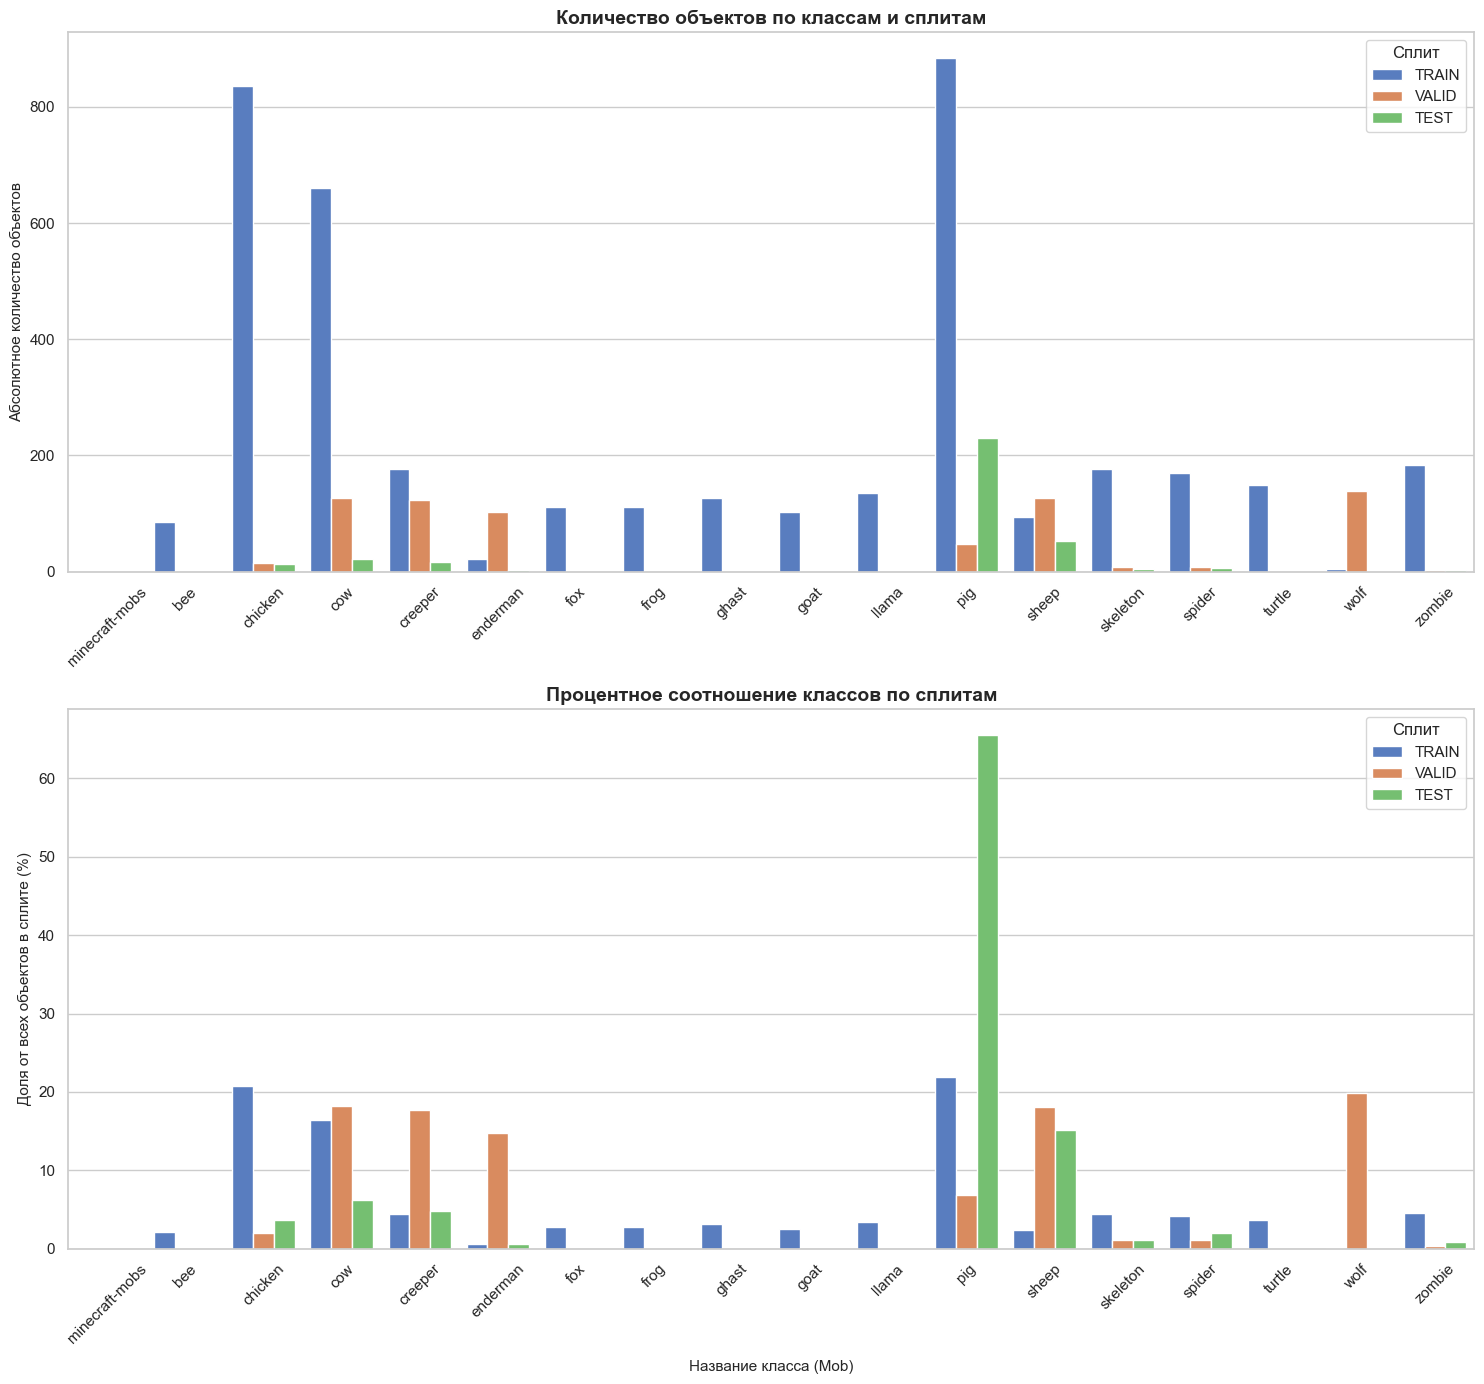


[INFO] Графики распределения сохранены в: artifacts\class_distribution_combined.png


In [1]:
from pathlib import Path
from scripts import cls_dispersion

# Пути к данным
annotations_dir = Path("datasets/minecraft/annotations")
splits = ["train", "valid", "test"]


cls_dispersion (annotations_dir, splits)
    

- Классы- призраки во валидации: Классы bee, fox, frog, ghast, goat, llama, turtle имеют объекты в TRAIN, но полностью отсутствуют (0 объектов) в VALID и TEST. Модели научатся их детектировать, но метрики (mAP) по ним вы не узнаете. 
- Аномалия с классом wolf: В TRAIN всего 4 волка (0.10%), зато в VALID их аж 138 (19.80%), а в TEST снова 0. Модель физически не сможет выучить этот класс по 4 примерам, и валидация на нем полностью провалится. 
- Перекос TEST сплита: В TEST выборке класс pig занимает 65.53% всех объектов. Оценка mAP будет отражать только качество детектирования свиней. 
- Пустой класс: Класс minecraft-mobs равен 0 везде. Его нужно удалить из конфигурации (оставить 17 классов вместо 18).

### Визуализируйте один тестовый пример. Отрисуйте одно тестовое изображение с выделенными на нём bounding box'ами и подписанными классами

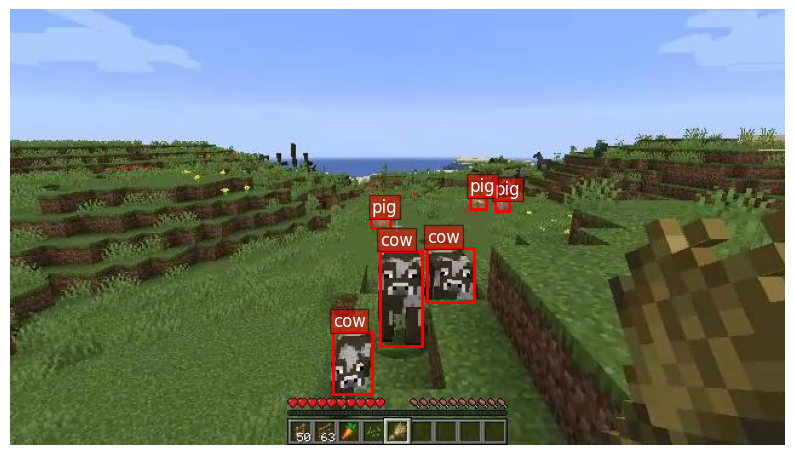

In [1]:
from scripts import vis_test
from pathlib import Path


annotations_dir = Path("datasets/minecraft/annotations/")
image_dir = Path("datasets/minecraft/test")


vis_test(annotations_dir, image_dir)
    

In [1]:

from pathlib import Path
from scripts import img_per_obj

annotations_dir = Path("datasets/minecraft/annotations/")

img_per_obj(annotations_dir)
    

Класс                | Кол-во уникальных картинок
--------------------------------------------------
pig                  | 80                       
sheep                | 43                       
creeper              | 17                       
cow                  | 10                       
spider               | 7                        
chicken              | 5                        
skeleton             | 4                        
zombie               | 2                        
enderman             | 2                        
--------------------------------------------------
Всего изображений в датасете: 155
Из них имеют хотя бы одну аннотацию: 155


loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Путь к изображению: datasets/minecraft/train\snow_-_pig_1215_jpg.rf.004b081d444fa45d89e051a2d793ac9c.jpg


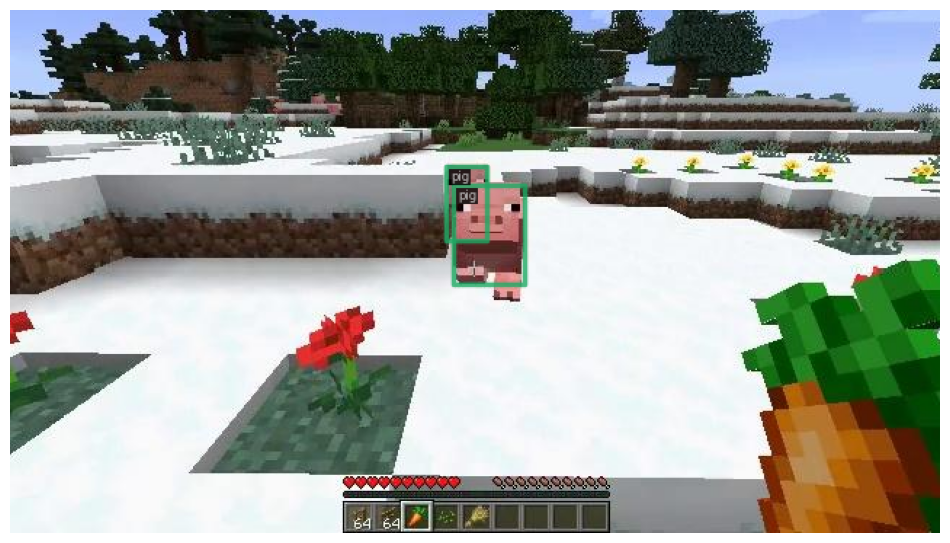

In [1]:
from dataset_demonstration import visialize_sample

visialize_sample()

## Этап 3. Настройка конфигурации моделей

configs/fcos/fcos_minecraft.py  
mmdet/datasets/coco_minecraft.py

### Перед обучением протестируйте инференс на pretrained-модели FCOS в ноутбуке.

Loads checkpoint by local backend from path: checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco-821213aa.pth
The model and loaded state dict do not match exactly

size mismatch for bbox_head.conv_cls.weight: copying a param with shape torch.Size([80, 256, 3, 3]) from checkpoint, the shape in current model is torch.Size([18, 256, 3, 3]).
size mismatch for bbox_head.conv_cls.bias: copying a param with shape torch.Size([80]) from checkpoint, the shape in current model is torch.Size([18]).


c:\Users\esalmin\dev\dl_training\CV1\mmdetetion_workspace\.venv\lib\site-packages\mmengine\utils\manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


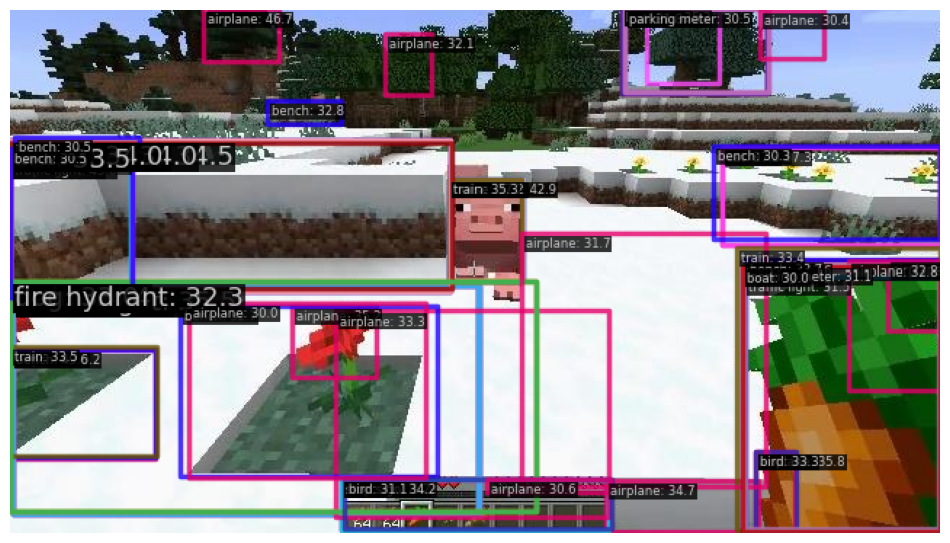

In [2]:
from test_inference_pt import test_inference_pt

test_inference_pt()

### Сначала подготовьте файл datasets/minecraft/data.yaml, чтобы YOLO работал с данными в корректной форме

datasets/minecraft/data.yaml

### Проверьте инференс на pretrained-модели YOLOv8s. Именно её вы будете дообучать. 


0: 384x640 1 person, 3 potted plants, 1 dining table, 289.5ms
Speed: 2.4ms preprocess, 289.5ms inference, 3.3ms postprocess per image at shape (1, 3, 384, 640)


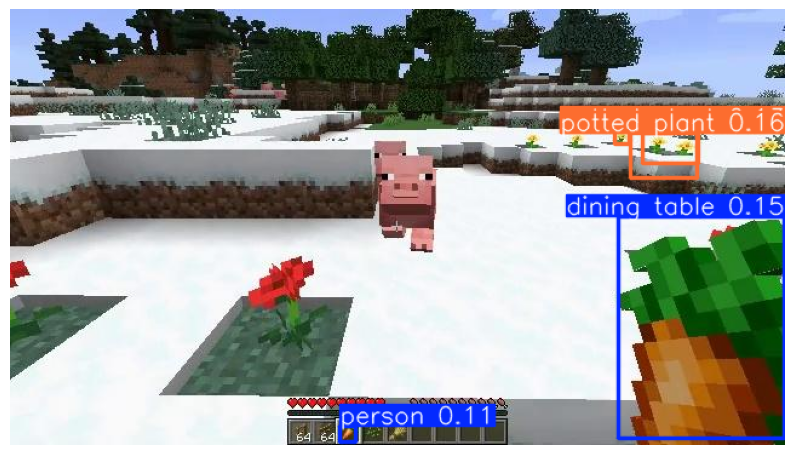

In [ ]:
from test_inference_pt_yolo import test_inference_pt_yolo

test_inference_pt_yolo()